# 06 — Analisis correlacional y de asociacion

**Objetivo especifico que responde:** OE-03/OE-04 del anteproyecto, seccion 3.4 ("Relacion logica entre variables") de `InformesRev/AnteproyectoAndres.md`: *"Desempeño contractual (Vc, Vt) = f (Modalidad + Tipo de contratista + Region + Cuantia + Sector)"* — esta seccion explora esa relacion mediante correlacion y asociacion, sin asumir un modelo de regresion formal, tal como aclara el propio anteproyecto en ese numeral.

**Advertencia metodologica:** correlacion/asociacion no implica causalidad. Este es un proyecto descriptivo-analitico, no causal ni predictivo.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

REPO = Path(".").resolve().parents[1] if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATA_DIR = REPO / "analitica-descriptiva-andres" / "data"
FIG_DIR = REPO / "analitica-descriptiva-andres" / "figuras"

df = pd.read_parquet(DATA_DIR / "indicadores_restriccion_hierro.parquet")
print("Indicadores cargados:", df.shape)


Indicadores cargados: (19194, 28)


## 1. Justificacion del coeficiente de correlacion

Las distribuciones de `valor_del_contrato`, `plazo_pactado_dias`, `plazo_real_dias`, `desviacion_tiempo_dias` y `desviacion_costo_pct` ya se mostraron fuertemente asimetricas y con outliers extremos en el notebook 04. Se verifica aqui formalmente el sesgo (skewness) antes de decidir el coeficiente:

In [2]:
variables_continuas = ['valor_del_contrato', 'plazo_pactado_dias', 'plazo_real_dias',
                        'desviacion_tiempo_dias', 'desviacion_costo_pct']

for v in variables_continuas:
    sk = df[v].dropna().skew()
    print(f"{v}: asimetria (skew) = {sk:.2f}")

print()
print("Todas las variables presentan |skew| sustancialmente mayor a 1, lo que descarta el supuesto de")
print("normalidad requerido por el coeficiente de Pearson. Se usa el coeficiente de Spearman (basado en rangos,")
print("no parametrico, robusto a asimetria y outliers) para todas las correlaciones de esta seccion.")


valor_del_contrato: asimetria (skew) = 20.13
plazo_pactado_dias: asimetria (skew) = 34.64
plazo_real_dias: asimetria (skew) = 3.80
desviacion_tiempo_dias: asimetria (skew) = -36.47
desviacion_costo_pct: asimetria (skew) = -2.77

Todas las variables presentan |skew| sustancialmente mayor a 1, lo que descarta el supuesto de
normalidad requerido por el coeficiente de Pearson. Se usa el coeficiente de Spearman (basado en rangos,
no parametrico, robusto a asimetria y outliers) para todas las correlaciones de esta seccion.


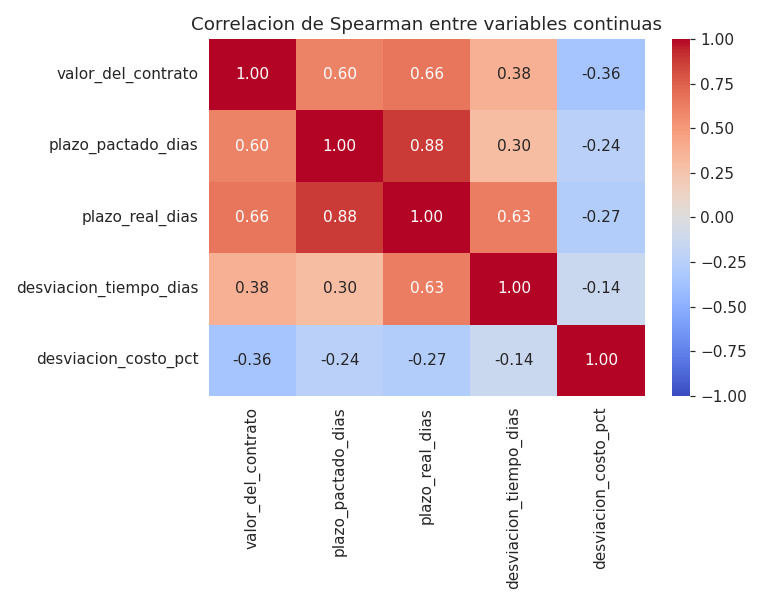

In [3]:
corr_spearman = df[variables_continuas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlacion de Spearman entre variables continuas")
plt.tight_layout()
ruta = FIG_DIR / "06_correlacion_spearman.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 2. Asociacion: modalidad de contratacion vs. indice de cumplimiento de alcance

Ambas variables son categoricas. Se usa la prueba **chi-cuadrado de independencia**, reportando el tamaño de efecto mediante la **V de Cramer** (no solo el p-valor), tal como exige el estandar de rigor de este ejercicio.

In [4]:
def cramers_v(tabla_contingencia):
    chi2, p, dof, expected = stats.chi2_contingency(tabla_contingencia)
    n = tabla_contingencia.sum().sum()
    r, k = tabla_contingencia.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1)))
    return chi2, p, dof, v

tabla_modalidad_alcance = pd.crosstab(df['modalidad_de_contratacion'], df['indice_alcance'])
chi2, p, dof, v = cramers_v(tabla_modalidad_alcance)
print(f"Chi-cuadrado = {chi2:.2f} | gl = {dof} | p-valor = {p:.2e} | V de Cramer = {v:.3f}")
print()
print("Interpretacion del tamaño de efecto (V de Cramer, regla de Cohen para tablas con gl>1):")
print("< 0.10 = insignificante | 0.10-0.20 = debil | 0.20-0.30 = moderado | > 0.30 = fuerte")


Chi-cuadrado = 2763.35 | gl = 16 | p-valor = 0.00e+00 | V de Cramer = 0.268

Interpretacion del tamaño de efecto (V de Cramer, regla de Cohen para tablas con gl>1):
< 0.10 = insignificante | 0.10-0.20 = debil | 0.20-0.30 = moderado | > 0.30 = fuerte


## 3. Asociacion: tipo de contratista vs. indice de cumplimiento de alcance

In [5]:
tabla_contratista_alcance = pd.crosstab(df['tipo_contratista'], df['indice_alcance'])
chi2_c, p_c, dof_c, v_c = cramers_v(tabla_contratista_alcance)
print(f"Chi-cuadrado = {chi2_c:.2f} | gl = {dof_c} | p-valor = {p_c:.2e} | V de Cramer = {v_c:.3f}")


Chi-cuadrado = 1300.56 | gl = 6 | p-valor = 8.18e-278 | V de Cramer = 0.184


## 4. Tabla resumen de asociaciones de esta seccion

In [6]:
resumen_asociaciones = pd.DataFrame([
    {'Prueba': 'Modalidad de contratacion vs. indice de alcance', 'Estadistico': f"chi2={chi2:.1f}",
     'p_valor': p, 'Tamano_efecto_V_Cramer': round(v, 3)},
    {'Prueba': 'Tipo de contratista vs. indice de alcance', 'Estadistico': f"chi2={chi2_c:.1f}",
     'p_valor': p_c, 'Tamano_efecto_V_Cramer': round(v_c, 3)},
])
resumen_asociaciones


,Prueba,Estadistico,p_valor,Tamano_efecto_V_Cramer
0,Modalidad de contratacion vs. indice de alcance,chi2=2763.4,0.000000e+00,0.268
1,Tipo de contratista vs. indice de alcance,chi2=1300.6,8.184846e-278,0.184


## 5. Sintesis de hallazgos de este notebook

- Se justifico y aplico el coeficiente de Spearman (no Pearson) para todas las correlaciones entre variables continuas, dado el sesgo severo (|skew| >> 1) verificado formalmente, no solo inspeccionado visualmente.
- Se reportan las asociaciones entre modalidad de contratacion / tipo de contratista y el indice de cumplimiento de alcance con prueba chi-cuadrado y tamaño de efecto (V de Cramer), no solo significancia estadistica — ver la tabla resumen para los valores exactos obtenidos.
- Ninguna asociacion aqui reportada se interpreta como relacion causal; el diseño del estudio es censal condicionado y transversal (numeral 3.1 y 3.6.2 del anteproyecto), no experimental.